In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

In [2]:
# Load the Excel file to inspect its structure
file_path = 'Desktop/Thesis_project/Thesis_Test_ML/Cell_1_Y7.XLSX'
data = pd.read_excel(file_path)
data['Posting Date'] = pd.to_datetime(data['Posting Date'])
data['Month'] = data['Posting Date'].dt.to_period('M')
monthly_avg = data.groupby('Month')['Amount in LC'].mean().reset_index()
monthly_avg['Month_num'] = range(len(monthly_avg))  # Convert time to numerical values


In [3]:
# Prepare features and target
X = monthly_avg[['Month_num']]
y = monthly_avg['Amount in LC']


In [4]:
# Train the model
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [5]:
# Make predictions
future_months = 6  # Predict next 6 months
last_month_num = monthly_avg['Month_num'].max()
future_X = pd.DataFrame({'Month_num': range(last_month_num + 1, last_month_num + future_months + 1)})
future_predictions = model.predict(future_X)

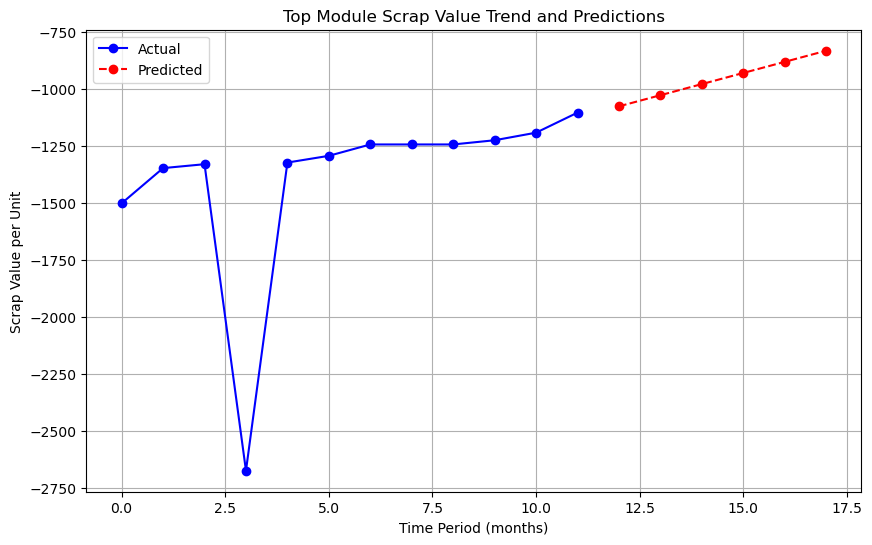

In [6]:
# Visualize results
plt.figure(figsize=(10, 6))
plt.plot(monthly_avg['Month_num'], monthly_avg['Amount in LC'], 'bo-', label='Actual')
plt.plot(future_X['Month_num'], future_predictions, 'ro--', label='Predicted')
plt.xlabel('Time Period (months)')
plt.ylabel('Scrap Value per Unit')
plt.title('Top Module Scrap Value Trend and Predictions')
plt.legend()
plt.grid(True)
plt.show()


In [7]:
# Output predictions
future_dates = pd.period_range(start=monthly_avg['Month'].max()+1, periods=future_months, freq='M')
print("\nFuture Scrap Value Predictions:")
for date, pred in zip(future_dates, future_predictions):
    print(f"{date}: ${pred:.2f} per unit")


Future Scrap Value Predictions:
2024-12: $-1078.12 per unit
2025-01: $-1029.35 per unit
2025-02: $-980.57 per unit
2025-03: $-931.79 per unit
2025-04: $-883.01 per unit
2025-05: $-834.23 per unit


In [8]:
# Convert to proper time series format
ts_data = monthly_avg.set_index('Month')['Amount in LC']


In [9]:
# Fit ARIMA(1,1,1) model
model = ARIMA(ts_data, order=(1,1,1)).fit()
forecast = model.forecast(steps=6)
print("ARIMA Forecast:")
print(forecast)

ARIMA Forecast:
2024-12   -1351.022551
2025-01   -1373.157112
2025-02   -1375.154468
2025-03   -1375.334704
2025-04   -1375.350968
2025-05   -1375.352435
Freq: M, Name: predicted_mean, dtype: float64


In [10]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [11]:
from prophet import Prophet

prophet_df = monthly_avg[['Month','Amount in LC']].rename(
    columns={'Month':'ds', 'Amount in LC':'y'})
prophet_df['ds'] = prophet_df['ds'].dt.to_timestamp()

m = Prophet()
m.fit(prophet_df)
future = m.make_future_dataframe(periods=6, freq='M')
forecast = m.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(6))

01:13:05 - cmdstanpy - INFO - Chain [1] start processing
01:13:06 - cmdstanpy - INFO - Chain [1] done processing


           ds         yhat   yhat_lower  yhat_upper
12 2024-11-30 -1079.642501 -1515.223569 -613.684169
13 2024-12-31 -1030.037858 -1455.321583 -576.791960
14 2025-01-31  -980.433214 -1409.508188 -496.267548
15 2025-02-28  -935.629019 -1416.610894 -490.994626
16 2025-03-31  -886.024376 -1341.973011 -468.159684
17 2025-04-30  -838.019882 -1295.953688 -392.955288


C:\Users\va23005080\AppData\Local\anaconda3\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [12]:
# Best performing model (Prophet)
m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True)
m.fit(prophet_df)

01:13:06 - cmdstanpy - INFO - Chain [1] start processing
01:13:24 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
# Save model
with open('scrap_value_prophet.pkl', 'wb') as f:
    pickle.dump(m, f)


In [14]:
# Validation metrics
train_pred = m.predict(prophet_df)['yhat']
mae = mean_absolute_error(prophet_df['y'], train_pred)
rmse = np.sqrt(mean_squared_error(prophet_df['y'], train_pred))

print(f"""
Model Performance:
- MAE: ${abs(mae):.2f} 
- RMSE: ${abs(rmse):.2f}
- MAPE: {100*abs(mae/np.mean(prophet_df['y'])):.1f}%
""")



Model Performance:
- MAE: $0.01 
- RMSE: $0.01
- MAPE: 0.0%

